# CNN con Triple Barrera de López de Prado

Este notebook transforma el problema de predicción de retornos en un problema de **clasificación multicategoría** usando triple barrera:

- `1`: toca primero la barrera superior.
- `0`: no toca ni arriba ni abajo durante la ventana vertical.
- `-1`: toca primero la barrera inferior.

La CNN recibe una ventana pasada de features y predice una clase por activo.

In [2]:
from __future__ import annotations

import math
import random
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import RobustScaler
from tensorflow.keras import layers, models

warnings.simplefilter(action="ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

RESULTS_DIR = Path("../results/cnn_triple_barrier_multiclass")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 1. Descarga de precios

Partimos de precios ajustados. El target de triple barrera se construye sobre precios, no sobre retornos.

In [3]:
START_DATE = "1945-01-01"

TICKERS_VALIDOS = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED", "GD",
    "GE", "HON", "HPQ", "IBM", "IP", "JNJ", "KO", "KR", "MMM",
    "MO", "MRK", "MSI", "PG", "XOM",
]

prices_close = yf.download(
    TICKERS_VALIDOS,
    start=START_DATE,
    auto_adjust=True,
    progress=False,
)["Close"]

prices_close = prices_close.dropna(axis=1, how="any").sort_index()
log_returns = np.log(prices_close).diff().dropna()

print(f"Precios: {prices_close.shape}")
print(f"Retornos logarítmicos: {log_returns.shape}")
print(f"Activos válidos: {list(prices_close.columns)}")

Precios: (16204, 23)
Retornos logarítmicos: (16203, 23)
Activos válidos: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 2. Volatilidad dinámica para las barreras

Usamos volatilidad EWMA diaria por activo. En la fecha `t`, la volatilidad solo usa información disponible hasta `t`; las barreras se evalúan desde `t+1` hasta `t+output_window`.

In [4]:
def compute_ewma_volatility(
    returns: pd.DataFrame,
    span: int = 63,
    min_periods: int = 20,
) -> pd.DataFrame:
    """Calcula volatilidad EWMA diaria por activo."""
    return returns.ewm(
        span=span,
        min_periods=min_periods,
        adjust=False,
    ).std()


daily_volatility = compute_ewma_volatility(
    returns=log_returns,
    span=63,
    min_periods=20,
)

daily_volatility.tail()

Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-14,0.013002,0.022365,0.025912,0.011220,0.015872,0.019022,0.012078,0.010390,0.016488,0.025457,...,0.030703,0.011048,0.010900,0.016357,0.016692,0.018044,0.015072,0.023609,0.013497,0.018413
2026-05-15,0.013642,0.023085,0.026489,0.011831,0.016158,0.019295,0.012885,0.010622,0.016532,0.025759,...,0.030994,0.011322,0.010742,0.016131,0.016497,0.017798,0.015165,0.023346,0.013345,0.019378
2026-05-18,0.013928,0.022722,0.026671,0.011680,0.016502,0.019102,0.012858,0.010653,0.016904,0.025541,...,0.030555,0.011285,0.010586,0.017023,0.017903,0.017546,0.015055,0.024303,0.013189,0.019235
2026-05-19,0.013822,0.022803,0.026286,0.011966,0.016408,0.019006,0.012864,0.010837,0.016710,0.025140,...,0.030505,0.011140,0.010493,0.017697,0.018024,0.017270,0.015054,0.024389,0.013037,0.019019
2026-05-20,0.013613,0.023160,0.025974,0.011778,0.016729,0.019112,0.012662,0.011083,0.016448,0.026045,...,0.031377,0.010971,0.010355,0.018171,0.017810,0.017071,0.014881,0.024007,0.012972,0.019530


## 3. Triple barrera multicategoría

Para cada activo y fecha `t`:

- Precio inicial: `p_t`.
- Barrera superior: `p_t * exp(pt_mult * sigma_t)`.
- Barrera inferior: `p_t * exp(-sl_mult * sigma_t)`.
- Horizonte vertical: `output_window` días.

La etiqueta será:

- `1` si toca arriba primero.
- `-1` si toca abajo primero.
- `0` si no toca ninguna barrera.



In [5]:
def get_first_barrier_touch_label(
    future_prices: np.ndarray,
    start_price: float,
    upper_barrier: float,
    lower_barrier: float,
) -> int:
    """Devuelve 1, 0 o -1 según la primera barrera tocada."""
    for price in future_prices:
        touched_upper = price >= upper_barrier
        touched_lower = price <= lower_barrier

        if touched_upper and touched_lower:
            future_return = np.log(price / start_price)
            if future_return > 0:
                return 1
            if future_return < 0:
                return -1
            return 0

        if touched_upper:
            return 1

        if touched_lower:
            return -1

    return 0


def make_triple_barrier_labels(
    prices: pd.DataFrame,
    volatility: pd.DataFrame,
    output_window: int,
    pt_mult: float = 1.0,
    sl_mult: float = 1.0,
) -> pd.DataFrame:
    """Construye etiquetas {-1, 0, 1} por fecha y activo."""
    common_index = prices.index.intersection(volatility.index)
    common_columns = prices.columns.intersection(volatility.columns)

    prices = prices.loc[common_index, common_columns].copy()
    volatility = volatility.loc[common_index, common_columns].copy()

    labels = pd.DataFrame(
        index=prices.index,
        columns=prices.columns,
        dtype="float64",
    )

    price_values = prices.to_numpy(dtype=float)
    vol_values = volatility.to_numpy(dtype=float)
    n_dates, n_assets = price_values.shape

    for asset_idx in range(n_assets):
        for t in range(n_dates - output_window):
            start_price = price_values[t, asset_idx]
            sigma_t = vol_values[t, asset_idx]

            if not np.isfinite(start_price) or not np.isfinite(sigma_t):
                continue
            if start_price <= 0 or sigma_t <= 0:
                continue

            future_prices = price_values[t + 1:t + output_window + 1, asset_idx]
            if not np.all(np.isfinite(future_prices)):
                continue

            upper_barrier = start_price * np.exp(pt_mult * sigma_t)
            lower_barrier = start_price * np.exp(-sl_mult * sigma_t)

            labels.iat[t, asset_idx] = get_first_barrier_touch_label(
                future_prices=future_prices,
                start_price=start_price,
                upper_barrier=upper_barrier,
                lower_barrier=lower_barrier,
            )

    return labels.dropna(how="all")

## 4. Features

Para centrar el notebook, usamos retornos logarítmicos como features. La CNN ve una ventana de retornos pasados de todos los activos.

No vamos a usar la diferenciación fraccional del anterior notebook.

In [6]:
features = log_returns.copy()
print(f"Features: {features.shape}")
features.head()

Features: (16203, 23)


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009694,-0.009820,-0.002259,0.013331,-0.008265,0.000000,0.032925,-0.010084,...,-0.013746,-0.015670,-0.022532,0.020791,0.007490,-0.018518,-0.042803,-0.002912,-0.010989,0.014743
1962-01-04,-0.014707,-0.009852,0.025398,0.000000,-0.009091,0.000000,-0.008333,-0.003092,0.004041,-0.011895,...,-0.003466,-0.010579,0.007570,-0.004124,0.000000,0.006984,-0.010255,-0.008785,-0.016716,0.002435
1962-01-05,-0.022472,-0.020000,0.009360,-0.024418,-0.025435,0.003308,-0.021144,-0.021910,0.004024,-0.025975,...,0.010364,-0.016089,-0.022875,-0.025107,-0.026466,0.011533,-0.034461,-0.005898,-0.007047,-0.022141
1962-01-08,-0.007604,0.002522,0.006193,-0.011301,-0.004695,-0.003308,0.002136,0.004735,0.015937,-0.001756,...,-0.020835,-0.016349,-0.010336,-0.004246,-0.005764,-0.006904,0.003043,-0.017912,-0.027241,-0.002491
1962-01-09,-0.007663,0.002515,0.009216,0.000000,0.014019,0.019677,0.002130,-0.001575,0.003945,0.005259,...,-0.014134,0.010931,0.018018,-0.021506,0.000000,-0.018648,0.004549,-0.024391,-0.001455,-0.002497


## 5. Codificación de etiquetas

Keras trabaja mejor con clases no negativas. Mapeamos:

```python
-1 -> 0
 0 -> 1
 1 -> 2
```

Pero en diagnósticos y salidas volvemos a `-1`, `0`, `1`.

In [7]:
LABEL_TO_CLASS = {-1: 0, 0: 1, 1: 2}
CLASS_TO_LABEL = {0: -1, 1: 0, 2: 1}
CLASS_NAMES = ["-1 abajo", "0 nada", "1 arriba"]


def encode_labels(labels: np.ndarray) -> np.ndarray:
    """Convierte etiquetas {-1, 0, 1} a clases {0, 1, 2}."""
    encoded = np.vectorize(LABEL_TO_CLASS.get)(labels.astype(int))
    return encoded.astype(np.int64)


def decode_classes(classes: np.ndarray) -> np.ndarray:
    """Convierte clases {0, 1, 2} a etiquetas {-1, 0, 1}."""
    decoded = np.vectorize(CLASS_TO_LABEL.get)(classes.astype(int))
    return decoded.astype(np.int64)

## 6. Dataset supervisado para CNN

Cada muestra es:

```python
X_t = retornos desde t-input_window+1 hasta t
y_t = etiqueta de triple barrera en t
```

`y_t` tiene una clase por activo.

In [8]:
def create_cnn_triple_barrier_dataset(
    features: pd.DataFrame,
    labels: pd.DataFrame,
    input_window: int,
) -> Tuple[np.ndarray, np.ndarray, pd.DatetimeIndex]:
    """Crea ventanas supervisadas para CNN."""
    common_index = features.index.intersection(labels.index)
    common_columns = features.columns.intersection(labels.columns)

    features_aligned = features.loc[common_index, common_columns].dropna(how="any")
    labels_aligned = labels.loc[features_aligned.index, common_columns].dropna(how="any")

    common_index = features_aligned.index.intersection(labels_aligned.index)
    features_aligned = features_aligned.loc[common_index]
    labels_aligned = labels_aligned.loc[common_index]

    x_values = features_aligned.to_numpy(dtype=np.float32)
    y_values = labels_aligned.to_numpy(dtype=np.int64)

    X: List[np.ndarray] = []
    y: List[np.ndarray] = []
    sample_dates: List[pd.Timestamp] = []

    for end_idx in range(input_window - 1, len(features_aligned)):
        x_window = x_values[end_idx - input_window + 1:end_idx + 1]
        y_label = y_values[end_idx]

        if not np.all(np.isfinite(x_window)):
            continue
        if not np.all(np.isfinite(y_label)):
            continue

        X.append(x_window)
        y.append(y_label)
        sample_dates.append(features_aligned.index[end_idx])

    X_array = np.asarray(X, dtype=np.float32)
    y_raw = np.asarray(y, dtype=np.int64)
    y_encoded = encode_labels(y_raw)

    return X_array, y_encoded, pd.DatetimeIndex(sample_dates)

## 7. Split cronológico y escalado sin leakage

El split es cronológico:

- train: tramo inicial.
- validation: tramo intermedio.
- test: tramo final.

El `RobustScaler` se ajusta solo con train.

In [9]:
def split_chronological(
    X: np.ndarray,
    y: np.ndarray,
    dates: pd.DatetimeIndex,
    val_size: float = 0.10,
    test_size: float = 0.10,
) -> Dict[str, Any]:
    """Split cronológico train / validation / test."""
    if val_size + test_size >= 1:
        raise ValueError("val_size + test_size debe ser menor que 1.")

    n_samples = len(X)
    test_start = int(n_samples * (1 - test_size))
    val_start = int(test_start * (1 - val_size))

    return {
        "X_train": X[:val_start],
        "X_val": X[val_start:test_start],
        "X_test": X[test_start:],
        "y_train": y[:val_start],
        "y_val": y[val_start:test_start],
        "y_test": y[test_start:],
        "dates_train": dates[:val_start],
        "dates_val": dates[val_start:test_start],
        "dates_test": dates[test_start:],
    }


def scale_cnn_features(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, RobustScaler]:
    """Escala features ajustando el scaler solo con train."""
    scaler = RobustScaler()
    n_features = X_train.shape[-1]

    scaler.fit(X_train.reshape(-1, n_features))

    X_train_n = scaler.transform(
        X_train.reshape(-1, n_features)
    ).reshape(X_train.shape)
    X_val_n = scaler.transform(
        X_val.reshape(-1, n_features)
    ).reshape(X_val.shape)
    X_test_n = scaler.transform(
        X_test.reshape(-1, n_features)
    ).reshape(X_test.shape)

    return X_train_n, X_val_n, X_test_n, scaler


def prepare_triple_barrier_cnn_data(
    features: pd.DataFrame,
    prices: pd.DataFrame,
    volatility: pd.DataFrame,
    input_window: int,
    output_window: int,
    pt_mult: float = 1.0,
    sl_mult: float = 1.0,
    val_size: float = 0.10,
    test_size: float = 0.10,
) -> Dict[str, Any]:
    """Pipeline completo de preparación de datos."""
    labels = make_triple_barrier_labels(
        prices=prices,
        volatility=volatility,
        output_window=output_window,
        pt_mult=pt_mult,
        sl_mult=sl_mult,
    )

    X, y, dates = create_cnn_triple_barrier_dataset(
        features=features,
        labels=labels,
        input_window=input_window,
    )

    split_data = split_chronological(
        X=X,
        y=y,
        dates=dates,
        val_size=val_size,
        test_size=test_size,
    )

    X_train_n, X_val_n, X_test_n, scaler_X = scale_cnn_features(
        X_train=split_data["X_train"],
        X_val=split_data["X_val"],
        X_test=split_data["X_test"],
    )

    split_data["X_train_n"] = X_train_n
    split_data["X_val_n"] = X_val_n
    split_data["X_test_n"] = X_test_n
    split_data["scaler_X"] = scaler_X
    split_data["labels_raw"] = labels

    return split_data

## 8. Balance de clases

Este diagnóstico es clave. Si casi todo es `0`, el modelo puede parecer bueno con accuracy alta y no estar aprendiendo dirección.

In [10]:
def summarize_class_balance(y: np.ndarray, title: str) -> pd.DataFrame:
    """Resume distribución de etiquetas reales {-1, 0, 1}."""
    flat_classes = y.reshape(-1)
    flat_labels = decode_classes(flat_classes)

    counts = pd.Series(flat_labels).value_counts().sort_index()
    summary = pd.DataFrame(
        {
            "label": counts.index,
            "count": counts.values,
            "pct": counts.values / counts.values.sum(),
        }
    )

    print(title)
    display(summary)
    return summary

## 9. Modelo CNN de clasificación multi-output

Entrada:

```python
(batch, input_window, n_features)
```

Salida:

```python
(batch, n_assets, 3)
```

Cada activo tiene 3 probabilidades: abajo, nada, arriba.

In [11]:
def build_cnn_triple_barrier_classifier(
    input_window: int,
    n_features: int,
    n_assets: int,
    n_classes: int = 3,
    kernel_size: Optional[int] = None,
    filters_1: int = 32,
    filters_2: int = 64,
    dense_units: int = 64,
    dropout_rate: float = 0.20,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    """CNN para clasificación {-1, 0, 1} por activo."""
    if kernel_size is None:
        kernel_size = math.ceil(input_window / 3)

    kernel_size = max(1, min(kernel_size, input_window))

    model = models.Sequential(
        [
            layers.Input(shape=(input_window, n_features)),
            layers.Conv1D(
                filters=filters_1,
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
            ),
            #layers.BatchNormalization(),
            layers.Conv1D(
                filters=filters_2,
                kernel_size=kernel_size,
                padding="same",
                activation="relu",
            ),
            #layers.BatchNormalization(),
            #layers.Dropout(dropout_rate),
            layers.GlobalAveragePooling1D(),
            layers.Dense(dense_units, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(n_assets * n_classes),
            layers.Reshape((n_assets, n_classes)),
            layers.Softmax(axis=-1),
        ]
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"],
    )

    return model

## 10. Métricas y gráficos

Usamos métricas agregadas sobre todas las fechas y activos:

- accuracy
- balanced accuracy
- macro F1
- weighted F1
- matriz de confusión

In [12]:
def predict_classes(model: tf.keras.Model, X: np.ndarray) -> np.ndarray:
    """Predice clases {0, 1, 2}."""
    probabilities = model.predict(X, verbose=0)
    return np.argmax(probabilities, axis=-1).astype(np.int64)


def compute_multiclass_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    prefix: str,
) -> Dict[str, float]:
    """Calcula métricas multicategoría agregadas."""
    y_true_flat = y_true.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    return {
        f"{prefix}_accuracy": accuracy_score(y_true_flat, y_pred_flat),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(
            y_true_flat,
            y_pred_flat,
        ),
        f"{prefix}_macro_f1": f1_score(
            y_true_flat,
            y_pred_flat,
            average="macro",
        ),
        f"{prefix}_weighted_f1": f1_score(
            y_true_flat,
            y_pred_flat,
            average="weighted",
        ),
    }


def print_classification_diagnostics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
) -> None:
    """Imprime classification report con etiquetas {-1, 0, 1}."""
    y_true_labels = decode_classes(y_true.reshape(-1))
    y_pred_labels = decode_classes(y_pred.reshape(-1))

    print(title)
    print(
        classification_report(
            y_true_labels,
            y_pred_labels,
            labels=[-1, 0, 1],
            target_names=CLASS_NAMES,
            zero_division=0,
        )
    )


def plot_training_history(
    history_df: pd.DataFrame,
    save_path: Optional[Path] = None,
) -> None:
    """Pinta loss y accuracy de train/validation."""
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(history_df["epoch"], history_df["loss"], label="Train loss")
    ax1.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Sparse categorical crossentropy")
    ax1.set_title("Evolución del entrenamiento")

    ax2 = ax1.twinx()
    ax2.plot(
        history_df["epoch"],
        history_df["sparse_categorical_accuracy"],
        label="Train accuracy",
        linestyle="--",
    )
    ax2.plot(
        history_df["epoch"],
        history_df["val_sparse_categorical_accuracy"],
        label="Validation accuracy",
        linestyle="--",
    )
    ax2.set_ylabel("Accuracy")

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

    fig.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix_labels(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    title: str,
    save_path: Optional[Path] = None,
) -> None:
    """Pinta matriz de confusión en etiquetas {-1, 0, 1}."""
    y_true_labels = decode_classes(y_true.reshape(-1))
    y_pred_labels = decode_classes(y_pred.reshape(-1))

    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=[-1, 0, 1])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.figure.colorbar(im, ax=ax)

    ax.set_xticks(np.arange(3))
    ax.set_yticks(np.arange(3))
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

## 11. Experimento individual

Este bloque entrena una CNN para una combinación concreta de `input_window` y `output_window`.

Decidimos mantener el shuffle en False por el cambio de estrategia

In [13]:
from sklearn.utils.class_weight import compute_class_weight

In [19]:
def run_single_triple_barrier_experiment(
    features: pd.DataFrame,
    prices: pd.DataFrame,
    volatility: pd.DataFrame,
    input_window: int,
    output_window: int,
    pt_mult: float = 1.0,
    sl_mult: float = 1.0,
    results_dir: Path = RESULTS_DIR,
    epochs: int = 200,
    batch_size: int = 64,
    kernel_size: Optional[int] = 3,
    filters_1: int = 32,
    filters_2: int = 64,
    dense_units: int = 64,
    dropout_rate: float = 0.20,
    learning_rate: float = 1e-3,
    verbose: int = 1,
) -> Dict[str, Any]:
    """Ejecuta un experimento completo CNN + triple barrera."""
    experiment_name = (
        f"cnn_tb_iw_{input_window}_ow_{output_window}"
        f"_pt_{pt_mult:g}_sl_{sl_mult:g}"
    )
    experiment_dir = results_dir / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    data = prepare_triple_barrier_cnn_data(
        features=features,
        prices=prices,
        volatility=volatility,
        input_window=input_window,
        output_window=output_window,
        pt_mult=pt_mult,
        sl_mult=sl_mult,
        val_size=0.10,
        test_size=0.10,
    )

    summarize_class_balance(data["y_train"], "Balance train")
    summarize_class_balance(data["y_val"], "Balance validation")
    summarize_class_balance(data["y_test"], "Balance test")

    model = build_cnn_triple_barrier_classifier(
        input_window=input_window,
        n_features=data["X_train_n"].shape[-1],
        n_assets=data["y_train"].shape[-1],
        n_classes=3,
        kernel_size=kernel_size,
        filters_1=filters_1,
        filters_2=filters_2,
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
    )

    best_model_path = experiment_dir / "best_model.keras"
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=30,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    print(
        f"Entrenando {experiment_name} | "
        f"params={model.count_params():,} | kernel={kernel_size}"
    )

   
    # Labels reales: shape posiblemente (n_samples, n_assets)
    y_train_fit = data["y_train"].astype(int)

    classes = np.unique(y_train_fit)

    class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_fit.ravel(),
    )

    class_weight_map = dict(zip(classes, class_weights_array))

    print("Class weights:", class_weight_map)

    # sample_weight con la misma forma que y_train: (n_samples, n_assets)

    sample_weight_train = np.vectorize(class_weight_map.get)(y_train_fit)


    history = model.fit(
        data["X_train_n"],
        data["y_train"],
        validation_data=(data["X_val_n"], data["y_val"]),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        sample_weight=sample_weight_train,
        shuffle=False,
        verbose=verbose,
    )

    best_model = tf.keras.models.load_model(best_model_path)

    y_train_pred = predict_classes(best_model, data["X_train_n"])
    y_val_pred = predict_classes(best_model, data["X_val_n"])
    y_test_pred = predict_classes(best_model, data["X_test_n"])

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    metrics = {
        "experiment_name": experiment_name,
        "input_window": input_window,
        "output_window": output_window,
        "pt_mult": pt_mult,
        "sl_mult": sl_mult,
        "kernel_size": kernel_size,
        "epochs_run": len(history.history["loss"]),
        "batch_size": batch_size,
        "n_params": int(best_model.count_params()),
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "best_val_loss": float(np.min(history.history["val_loss"])),
    }

    metrics.update(compute_multiclass_metrics(data["y_train"], y_train_pred, "train"))
    metrics.update(compute_multiclass_metrics(data["y_val"], y_val_pred, "val"))
    metrics.update(compute_multiclass_metrics(data["y_test"], y_test_pred, "test"))

    history_df.to_csv(experiment_dir / "history.csv", index=False)
    pd.DataFrame([metrics]).to_csv(experiment_dir / "metrics.csv", index=False)

    np.save(experiment_dir / "y_train_true_classes.npy", data["y_train"])
    np.save(experiment_dir / "y_val_true_classes.npy", data["y_val"])
    np.save(experiment_dir / "y_test_true_classes.npy", data["y_test"])
    np.save(experiment_dir / "y_train_pred_classes.npy", y_train_pred)
    np.save(experiment_dir / "y_val_pred_classes.npy", y_val_pred)
    np.save(experiment_dir / "y_test_pred_classes.npy", y_test_pred)

    pd.Series(data["dates_train"].astype(str)).to_csv(
        experiment_dir / "dates_train.csv",
        index=False,
        header=["date"],
    )
    pd.Series(data["dates_val"].astype(str)).to_csv(
        experiment_dir / "dates_val.csv",
        index=False,
        header=["date"],
    )
    pd.Series(data["dates_test"].astype(str)).to_csv(
        experiment_dir / "dates_test.csv",
        index=False,
        header=["date"],
    )

    plot_training_history(
        history_df=history_df,
        save_path=experiment_dir / "training_history.png",
    )
    plot_confusion_matrix_labels(
        y_true=data["y_test"],
        y_pred=y_test_pred,
        title="Matriz de confusión - Test",
        save_path=experiment_dir / "confusion_matrix_test.png",
    )
    print_classification_diagnostics(
        y_true=data["y_test"],
        y_pred=y_test_pred,
        title="Classification report - Test",
    )

    return {
        "model": best_model,
        "history": history_df,
        "metrics": metrics,
        "data": data,
        "experiment_dir": experiment_dir,
        "y_train_pred": y_train_pred,
        "y_val_pred": y_val_pred,
        "y_test_pred": y_test_pred,
    }

Balance train


,label,count,pct
0,-1,94895,0.317082
1,0,75905,0.253629
2,1,128476,0.429289


Balance validation


,label,count,pct
0,-1,10645,0.320073
1,0,8747,0.263004
2,1,13866,0.416922


Balance test


,label,count,pct
0,-1,11669,0.315711
1,0,10640,0.287871
2,1,14652,0.396418


Entrenando cnn_tb_iw_90_ow_30_pt_4_sl_4 | params=12,805 | kernel=3
Class weights: {np.int64(0): np.float64(1.051253139434814), np.int64(1): np.float64(1.3142568561579167), np.int64(2): np.float64(0.7764770592691761)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.1002 - sparse_categorical_accuracy: 0.3280 - val_loss: 1.0992 - val_sparse_categorical_accuracy: 0.3232 - learning_rate: 1.0000e-04
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0984 - sparse_categorical_accuracy: 0.3326 - val_loss: 1.0991 - val_sparse_categorical_accuracy: 0.3124 - learning_rate: 1.0000e-04
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0979 - sparse_categorical_accuracy: 0.3288 - val_loss: 1.0994 - val_sparse_categorical_accuracy: 0.3174 - learning_rate: 1.0000e-04
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0975 - sparse_categorical_accuracy: 0.3243 - val_loss: 1.0996 - val_sparse_categorical_accuracy: 0.3095 - learning_rate: 1.0000e-04

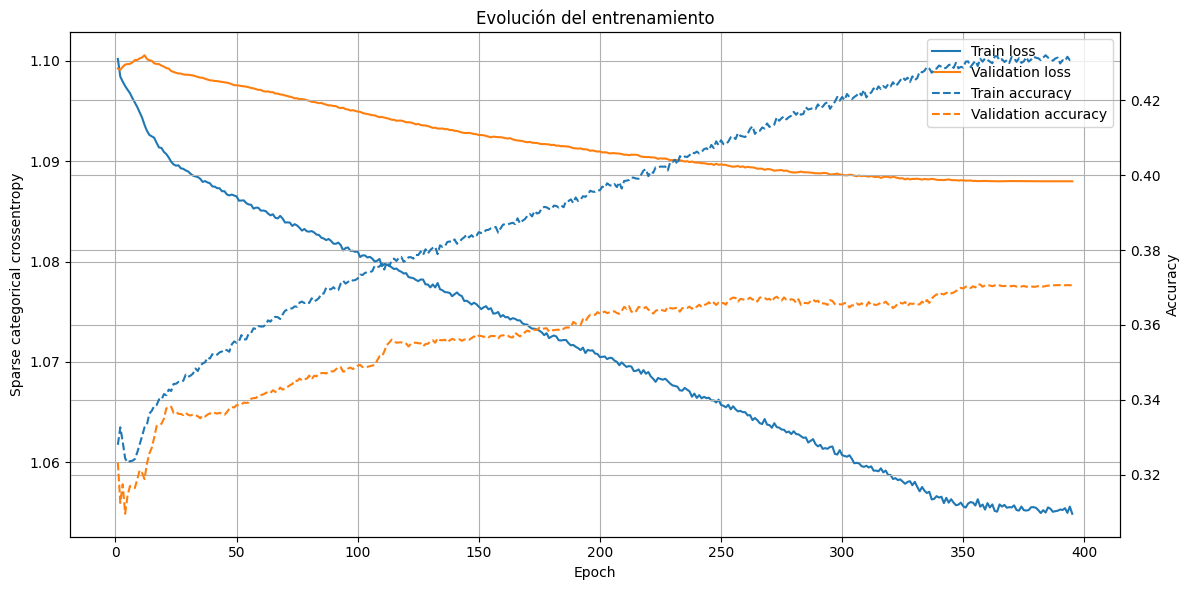

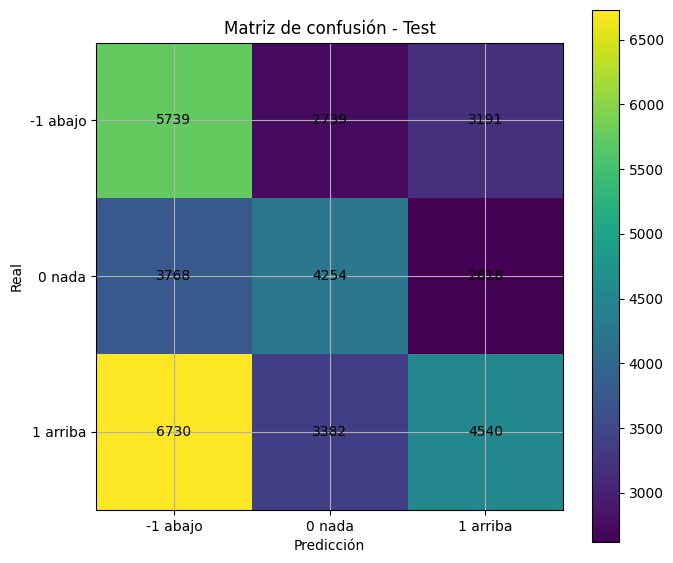

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.35      0.49      0.41     11669
      0 nada       0.41      0.40      0.40     10640
    1 arriba       0.44      0.31      0.36     14652

    accuracy                           0.39     36961
   macro avg       0.40      0.40      0.39     36961
weighted avg       0.40      0.39      0.39     36961



,experiment_name,input_window,output_window,pt_mult,sl_mult,kernel_size,epochs_run,batch_size,n_params,best_epoch,...,train_macro_f1,train_weighted_f1,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,cnn_tb_iw_90_ow_30_pt_4_sl_4,90,30,4.0,4.0,3,395,64,12805,365,...,0.435768,0.435421,0.370557,0.345907,0.343031,0.358996,0.393198,0.400494,0.393116,0.390374


In [15]:
# EMpezamos probando esto y ya haremos el grid

single_result = run_single_triple_barrier_experiment(
    features=features,
    prices=prices_close,
    volatility=daily_volatility,
    input_window=90,
    output_window=30,
    pt_mult=4.0,
    sl_mult=4.0,
    results_dir=RESULTS_DIR,
    epochs=1000,
    batch_size=64,
    kernel_size=3,
    filters_1=32,
    filters_2=64,
    dense_units=32,
    dropout_rate=0.15,
    learning_rate=0.0001,
    verbose=1,
)

pd.DataFrame([single_result["metrics"]])

## 12. Grid de ventanas

Este bloque lanza el grid `input_window x output_window`. Lo dejo comentado para que no se ejecute accidentalmente después del experimento individual.

In [20]:
def run_triple_barrier_grid(
    features: pd.DataFrame,
    prices: pd.DataFrame,
    volatility: pd.DataFrame,
    input_windows: List[int],
    output_windows: List[int],
    pt_mult: float = 4.0,
    sl_mult: float = 4.0,
    results_dir: Path = RESULTS_DIR,
    epochs: int = 200,
    batch_size: int = 64,
    kernel_size: Optional[int] = 3,
    filters_1: int = 32,
    filters_2: int = 64,
    dense_units: int = 32,
    dropout_rate: float = 0.15,
    learning_rate: float = 0.0001,
    verbose: int = 1,
) -> Tuple[pd.DataFrame, Dict[str, Dict[str, Any]]]:
    """Ejecuta grid de CNN + triple barrera."""
    all_results: Dict[str, Dict[str, Any]] = {}
    all_metrics: List[Dict[str, Any]] = []

    for input_window in input_windows:
        for output_window in output_windows:
            result = run_single_triple_barrier_experiment(
                features=features,
                prices=prices,
                volatility=volatility,
                input_window=input_window,
                output_window=output_window,
                pt_mult=pt_mult,
                sl_mult=sl_mult,
                results_dir=results_dir,
                epochs=epochs,
                batch_size=batch_size,
                kernel_size=kernel_size,
                filters_1=filters_1,
                filters_2=filters_2,
                dense_units=dense_units,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate,
                verbose=verbose,
            )

            key = f"iw_{input_window}_ow_{output_window}"
            all_results[key] = result
            all_metrics.append(result["metrics"])

    summary_df = pd.DataFrame(all_metrics)
    summary_df = summary_df.sort_values(
        ["test_macro_f1", "test_balanced_accuracy"],
        ascending=False,
    ).reset_index(drop=True)

    summary_df.to_csv(results_dir / "summary_all_experiments.csv", index=False)
    return summary_df, all_results

Balance train


,label,count,pct
0,-1,65888,0.218662
1,0,158394,0.525662
2,1,77041,0.255676


Balance validation


,label,count,pct
0,-1,6718,0.200609
1,0,18782,0.560858
2,1,7988,0.238533


Balance test


,label,count,pct
0,-1,7656,0.205729
1,0,20770,0.558123
2,1,8788,0.236148


Entrenando cnn_tb_iw_5_ow_5_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(1.5244202282661485), np.int64(1): np.float64(0.6341212419662361), np.int64(2): np.float64(1.303734375202814)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1.0992 - sparse_categorical_accuracy: 0.3301 - val_loss: 1.0919 - val_sparse_categorical_accuracy: 0.4079 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0969 - sparse_categorical_accuracy: 0.3567 - val_loss: 1.0848 - val_sparse_categorical_accuracy: 0.4518 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.0950 - sparse_categorical_accuracy: 0.3775 - val_loss: 1.0791 - val_sparse_categorical_accuracy: 0.4623 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0926 - sparse_categorical_accuracy: 0.3809 - val_loss: 1.0816 - val_sparse_categorical_accuracy: 0.4414 - learning_rate: 0.0010
Epoch 5/1000
205

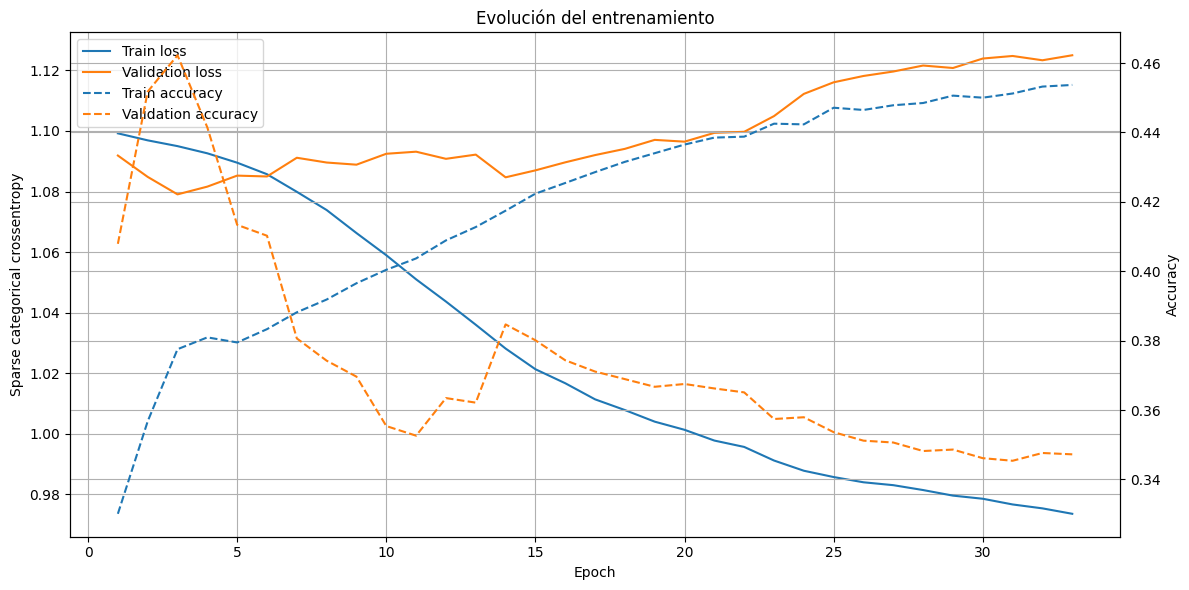

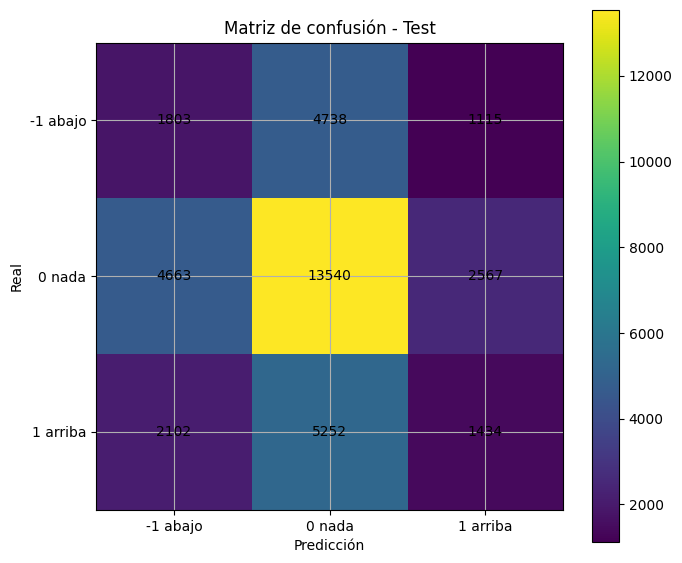

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.21      0.24      0.22      7656
      0 nada       0.58      0.65      0.61     20770
    1 arriba       0.28      0.16      0.21      8788

    accuracy                           0.45     37214
   macro avg       0.36      0.35      0.35     37214
weighted avg       0.43      0.45      0.44     37214

Balance train


,label,count,pct
0,-1,134527,0.447137
1,0,6009,0.019973
2,1,160327,0.532890


Balance validation


,label,count,pct
0,-1,13964,0.417559
1,0,783,0.023414
2,1,18695,0.559028


Balance test


,label,count,pct
0,-1,16431,0.442348
1,0,1022,0.027514
2,1,19692,0.530139


Entrenando cnn_tb_iw_5_ow_30_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7454835584430387), np.int64(1): np.float64(16.689576745992124), np.int64(2): np.float64(0.6255195111657217)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.1003 - sparse_categorical_accuracy: 0.3525 - val_loss: 1.0956 - val_sparse_categorical_accuracy: 0.3058 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0909 - sparse_categorical_accuracy: 0.3342 - val_loss: 1.1024 - val_sparse_categorical_accuracy: 0.2940 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0863 - sparse_categorical_accuracy: 0.3246 - val_loss: 1.1138 - val_sparse_categorical_accuracy: 0.2746 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0846 - sparse_categorical_accuracy: 0.3210 - val_loss: 1.1146 - val_sparse_categorical_accuracy: 0.2727 - learning_rate: 0.0010
Epoch 5/1000
20

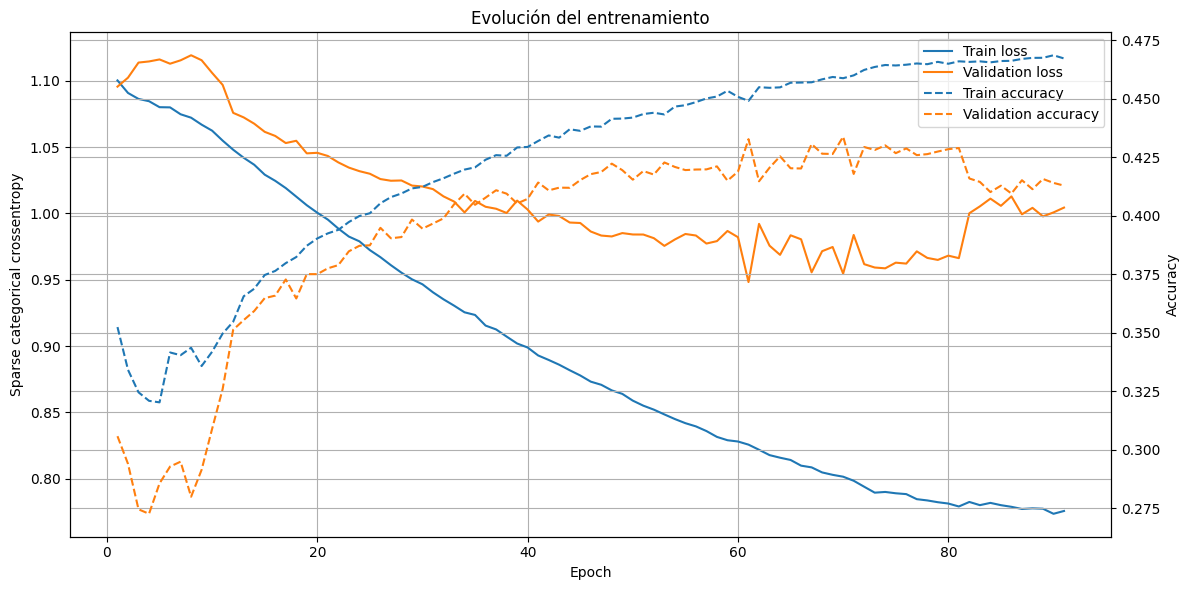

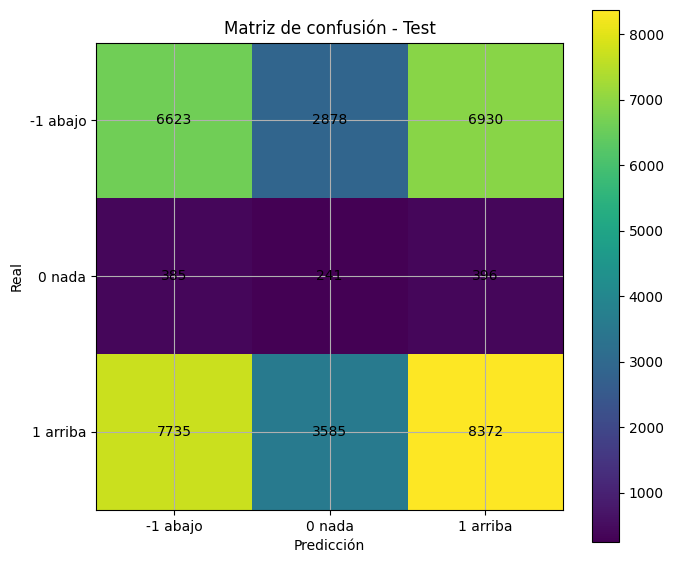

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.45      0.40      0.42     16431
      0 nada       0.04      0.24      0.06      1022
    1 arriba       0.53      0.43      0.47     19692

    accuracy                           0.41     37145
   macro avg       0.34      0.35      0.32     37145
weighted avg       0.48      0.41      0.44     37145

Balance train


,label,count,pct
0,-1,136602,0.455741
1,0,133,0.000444
2,1,163001,0.543815


Balance validation


,label,count,pct
0,-1,14233,0.427071
1,1,19094,0.572929


Balance test


,label,count,pct
0,-1,16798,0.453914
1,0,21,0.000567
2,1,20188,0.545518


Entrenando cnn_tb_iw_5_ow_90_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7314094962006413), np.int64(1): np.float64(751.218045112782), np.int64(2): np.float64(0.6129532947650628)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.9643 - sparse_categorical_accuracy: 0.4856 - val_loss: 0.8510 - val_sparse_categorical_accuracy: 0.5260 - learning_rate: 0.0010
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.4147 - sparse_categorical_accuracy: 0.5001 - val_loss: 0.8900 - val_sparse_categorical_accuracy: 0.5078 - learning_rate: 0.0010
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1357 - sparse_categorical_accuracy: 0.4907 - val_loss: 0.9050 - val_sparse_categorical_accuracy: 0.4975 - learning_rate: 0.0010
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0493 - sparse_categorical_accuracy: 0.4869 - val_loss: 0.8997 - val_sparse_categorical_accuracy: 0.4929 - learning_rate: 0.0010
Epoch 5/1000
204/

c:\Users\Miriamdbg\anaconda3\envs\entorno_rnn\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


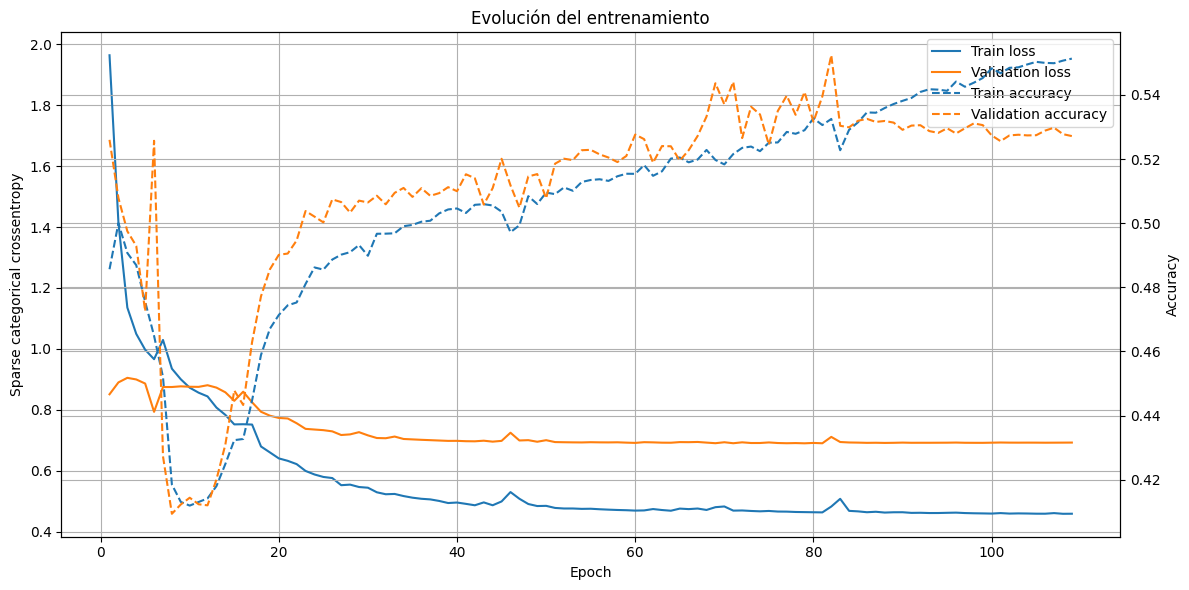

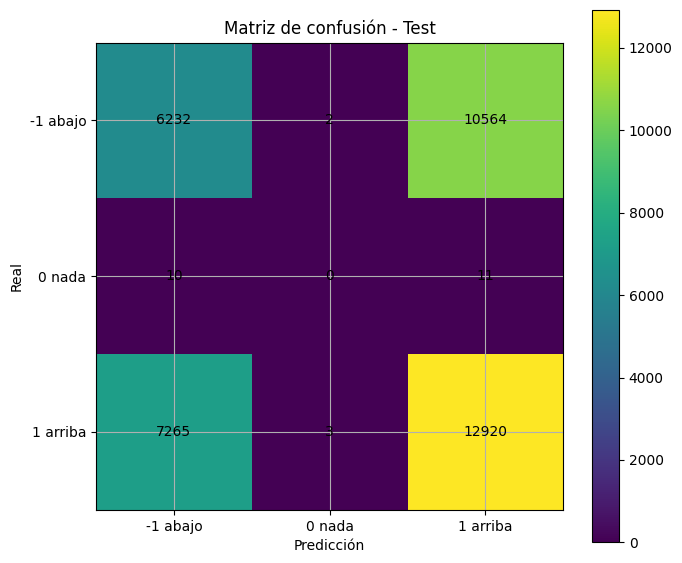

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.46      0.37      0.41     16798
      0 nada       0.00      0.00      0.00        21
    1 arriba       0.55      0.64      0.59     20188

    accuracy                           0.52     37007
   macro avg       0.34      0.34      0.33     37007
weighted avg       0.51      0.52      0.51     37007

Balance train


,label,count,pct
0,-1,65870,0.218669
1,0,158346,0.525663
2,1,77015,0.255668


Balance validation


,label,count,pct
0,-1,6718,0.200609
1,0,18782,0.560858
2,1,7988,0.238533


Balance test


,label,count,pct
0,-1,7655,0.205829
1,0,20750,0.557931
2,1,8786,0.236240


Entrenando cnn_tb_iw_10_ow_5_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(1.524371236273468), np.int64(1): np.float64(0.6341197967320509), np.int64(2): np.float64(1.3037763206301802)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0989 - sparse_categorical_accuracy: 0.3337 - val_loss: 1.0917 - val_sparse_categorical_accuracy: 0.4052 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0973 - sparse_categorical_accuracy: 0.3630 - val_loss: 1.0853 - val_sparse_categorical_accuracy: 0.4505 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0955 - sparse_categorical_accuracy: 0.3823 - val_loss: 1.0803 - val_sparse_categorical_accuracy: 0.4359 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0936 - sparse_categorical_accuracy: 0.3889 - val_loss: 1.0868 - val_sparse_categorical_accuracy: 0.3952 - learning_rate: 0.0010
Epoch 5/1000
205

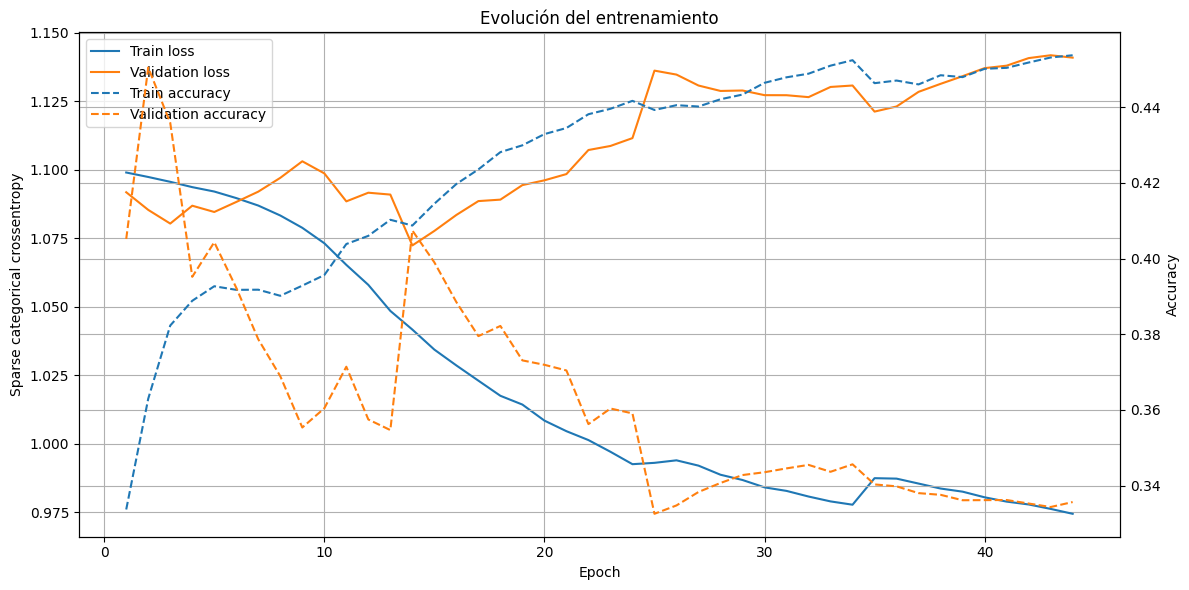

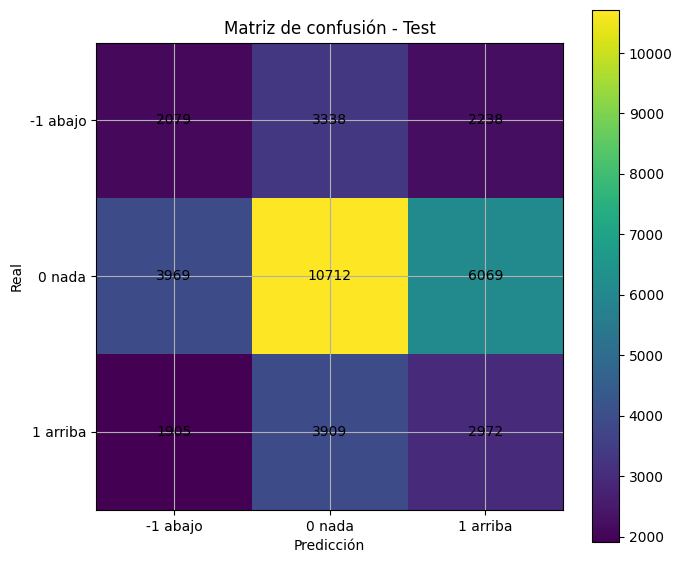

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.26      0.27      0.27      7655
      0 nada       0.60      0.52      0.55     20750
    1 arriba       0.26      0.34      0.30      8786

    accuracy                           0.42     37191
   macro avg       0.37      0.38      0.37     37191
weighted avg       0.45      0.42      0.43     37191

Balance train


,label,count,pct
0,-1,134475,0.447101
1,0,6004,0.019962
2,1,160292,0.532937


Balance validation


,label,count,pct
0,-1,13952,0.417487
1,0,783,0.023430
2,1,18684,0.559083


Balance test


,label,count,pct
0,-1,16431,0.442348
1,0,1022,0.027514
2,1,19692,0.530139


Entrenando cnn_tb_iw_10_ow_30_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7455437813720023), np.int64(1): np.float64(16.698367754830112), np.int64(2): np.float64(0.6254647767823722)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 1.0995 - sparse_categorical_accuracy: 0.3584 - val_loss: 1.0951 - val_sparse_categorical_accuracy: 0.3404 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0914 - sparse_categorical_accuracy: 0.3495 - val_loss: 1.0993 - val_sparse_categorical_accuracy: 0.3031 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0867 - sparse_categorical_accuracy: 0.3062 - val_loss: 1.1004 - val_sparse_categorical_accuracy: 0.2871 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0810 - sparse_categorical_accuracy: 0.3004 - val_loss: 1.1130 - val_sparse_categorical_accuracy: 0.2559 - learning_rate: 0.0010
Epoch 5/1000


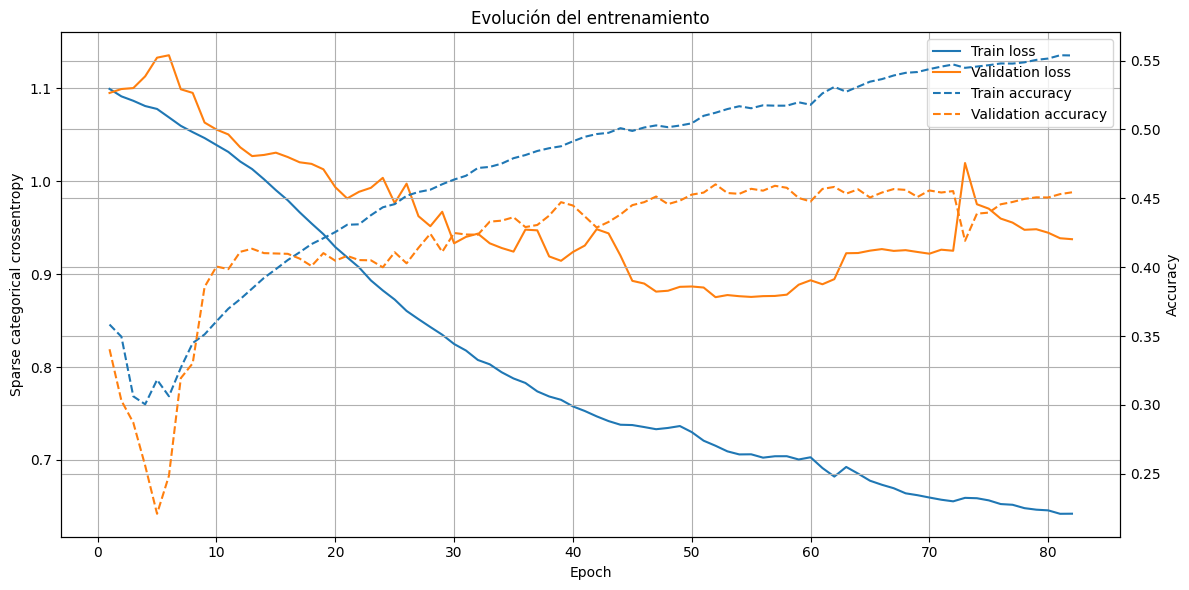

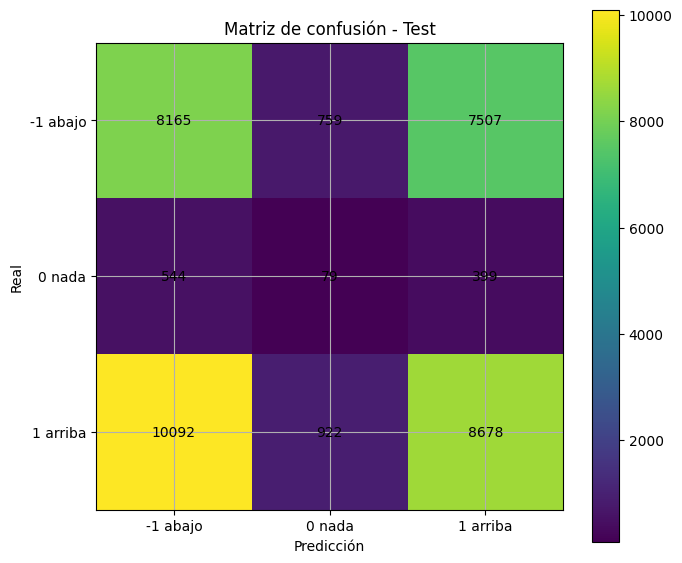

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.43      0.50      0.46     16431
      0 nada       0.04      0.08      0.06      1022
    1 arriba       0.52      0.44      0.48     19692

    accuracy                           0.46     37145
   macro avg       0.33      0.34      0.33     37145
weighted avg       0.47      0.46      0.46     37145

Balance train


,label,count,pct
0,-1,136541,0.455677
1,0,133,0.000444
2,1,162970,0.543879


Balance validation


,label,count,pct
0,-1,14227,0.427186
1,1,19077,0.572814


Balance test


,label,count,pct
0,-1,16798,0.453914
1,0,21,0.000567
2,1,20188,0.545518


Entrenando cnn_tb_iw_10_ow_90_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.731511658280907), np.int64(1): np.float64(750.9874686716792), np.int64(2): np.float64(0.6128817164713342)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.9601 - sparse_categorical_accuracy: 0.4862 - val_loss: 0.8634 - val_sparse_categorical_accuracy: 0.5014 - learning_rate: 0.0010
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3388 - sparse_categorical_accuracy: 0.4966 - val_loss: 0.7883 - val_sparse_categorical_accuracy: 0.5094 - learning_rate: 0.0010
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4594 - sparse_categorical_accuracy: 0.4836 - val_loss: 0.8301 - val_sparse_categorical_accuracy: 0.4880 - learning_rate: 0.0010
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2089 - sparse_categorical_accuracy: 0.4947 - val_loss: 0.8445 - val_sparse_categorical_accuracy: 0.5340 - learning_rate: 0.0010
Epoch 5/1000
204

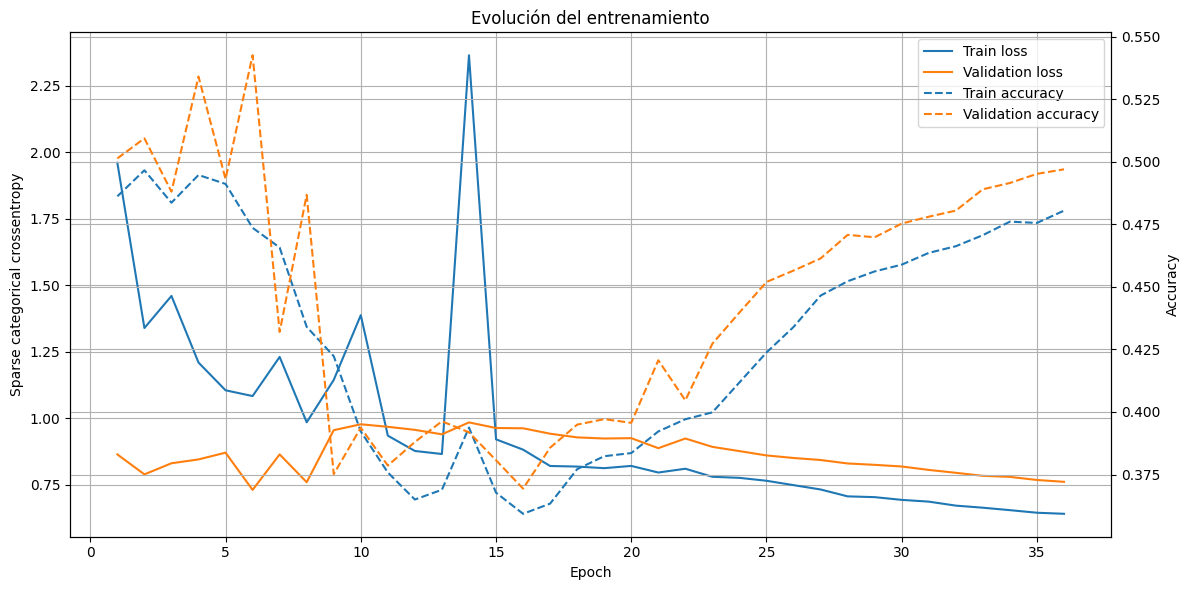

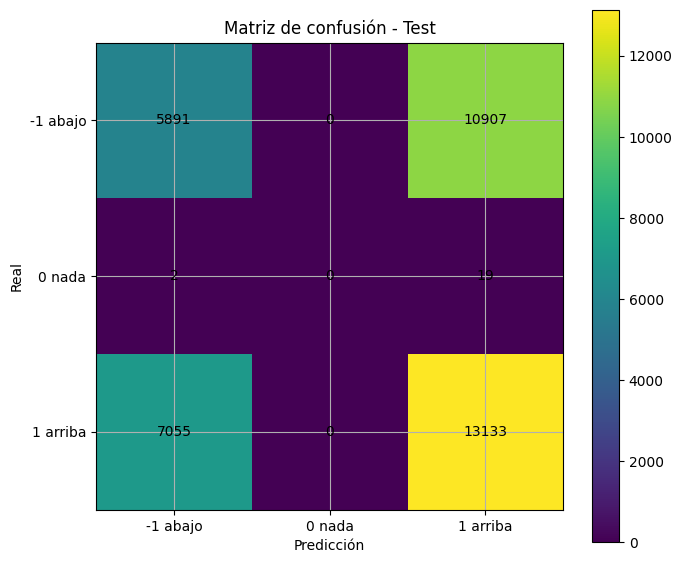

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.45      0.35      0.40     16798
      0 nada       0.00      0.00      0.00        21
    1 arriba       0.55      0.65      0.59     20188

    accuracy                           0.51     37007
   macro avg       0.33      0.33      0.33     37007
weighted avg       0.50      0.51      0.50     37007

Balance train


,label,count,pct
0,-1,65795,0.218688
1,0,158121,0.525558
2,1,76947,0.255754


Balance validation


,label,count,pct
0,-1,6713,0.200736
1,0,18756,0.560852
2,1,7973,0.238413


Balance test


,label,count,pct
0,-1,7653,0.206030
1,0,20713,0.557626
2,1,8779,0.236344


Entrenando cnn_tb_iw_30_ow_5_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(1.5242444967956026), np.int64(1): np.float64(0.634246347206675), np.int64(2): np.float64(1.303334329690133)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0988 - sparse_categorical_accuracy: 0.3413 - val_loss: 1.0908 - val_sparse_categorical_accuracy: 0.4342 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0977 - sparse_categorical_accuracy: 0.3600 - val_loss: 1.0822 - val_sparse_categorical_accuracy: 0.4448 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0969 - sparse_categorical_accuracy: 0.3759 - val_loss: 1.0889 - val_sparse_categorical_accuracy: 0.4266 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0959 - sparse_categorical_accuracy: 0.3850 - val_loss: 1.0987 - val_sparse_categorical_accuracy: 0.3267 - learning_rate: 0.0010
Epoch 5/1000
205/

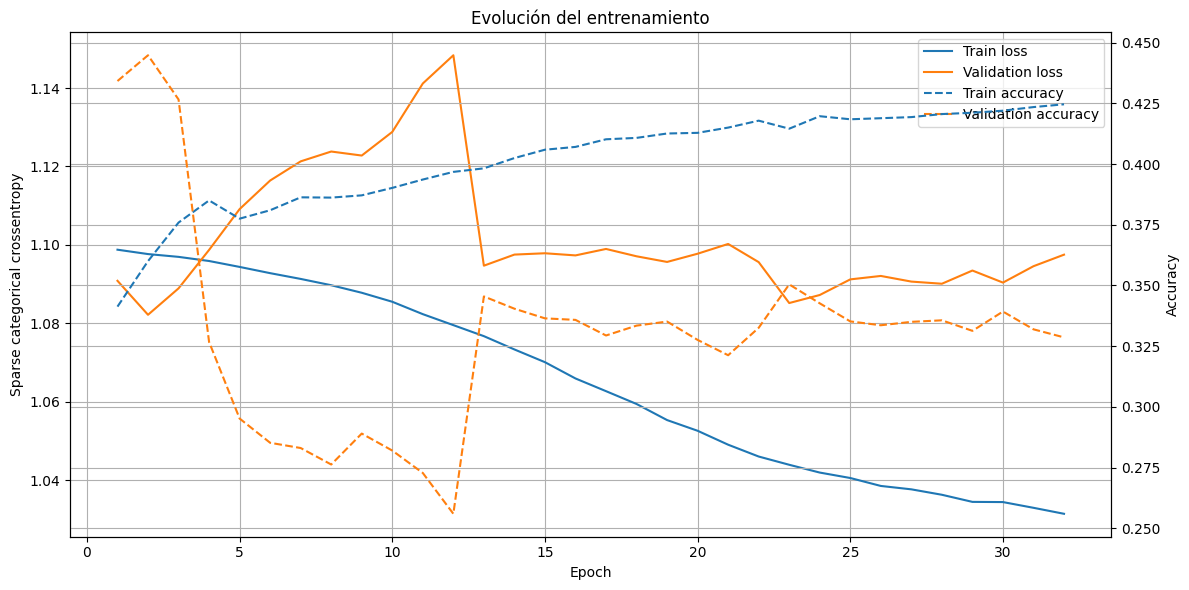

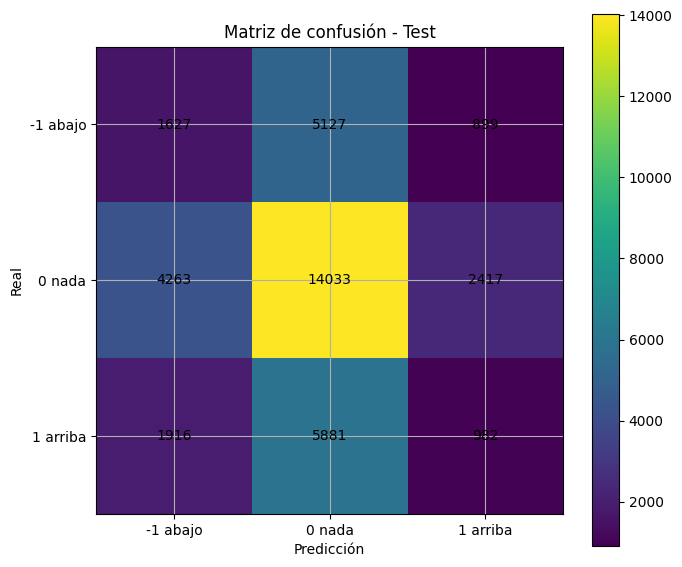

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.21      0.21      0.21      7653
      0 nada       0.56      0.68      0.61     20713
    1 arriba       0.23      0.11      0.15      8779

    accuracy                           0.45     37145
   macro avg       0.33      0.33      0.32     37145
weighted avg       0.41      0.45      0.42     37145

Balance train


,label,count,pct
0,-1,134297,0.447090
1,0,5978,0.019901
2,1,160105,0.533008


Balance validation


,label,count,pct
0,-1,13936,0.417295
1,0,787,0.023566
2,1,18673,0.559139


Balance test


,label,count,pct
0,-1,16413,0.442411
1,0,1018,0.027440
2,1,19668,0.530149


Entrenando cnn_tb_iw_30_ow_30_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7455614545869726), np.int64(1): np.float64(16.749191479870635), np.int64(2): np.float64(0.6253812602146508)}
Epoch 1/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.0962 - sparse_categorical_accuracy: 0.3389 - val_loss: 1.1047 - val_sparse_categorical_accuracy: 0.3045 - learning_rate: 0.0010
Epoch 2/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0877 - sparse_categorical_accuracy: 0.3213 - val_loss: 1.1001 - val_sparse_categorical_accuracy: 0.2984 - learning_rate: 0.0010
Epoch 3/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0852 - sparse_categorical_accuracy: 0.3126 - val_loss: 1.1034 - val_sparse_categorical_accuracy: 0.2708 - learning_rate: 0.0010
Epoch 4/1000
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0823 - sparse_categorical_accuracy: 0.2947 - val_loss: 1.1018 - val_sparse_categorical_accuracy: 0.2939 - learning_rate: 0.0010
Epoch 5/1000
2

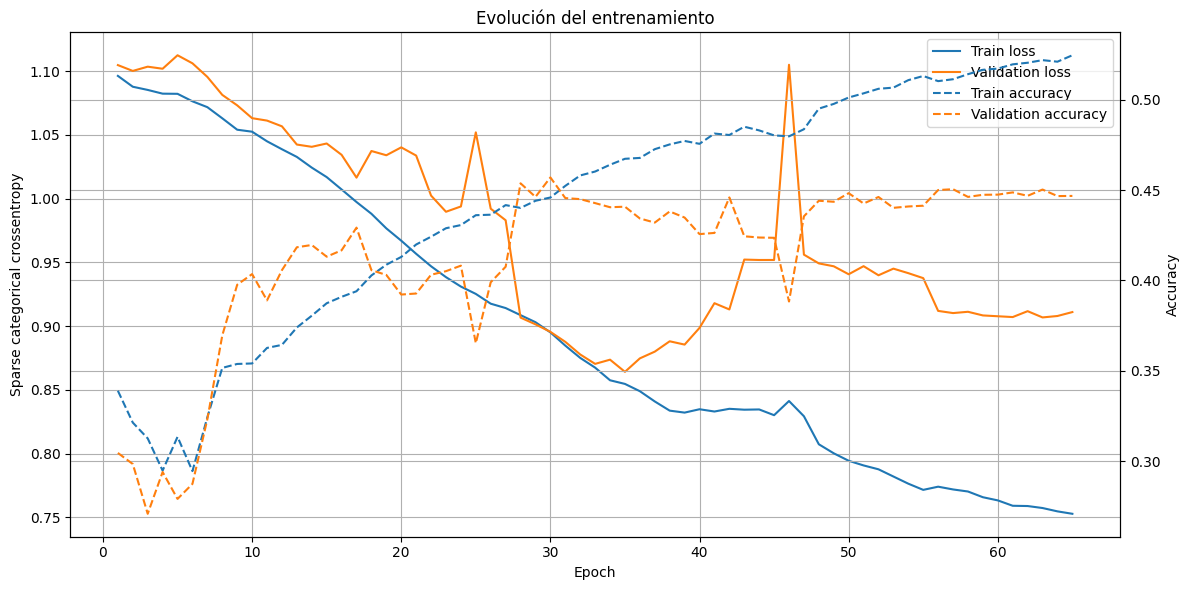

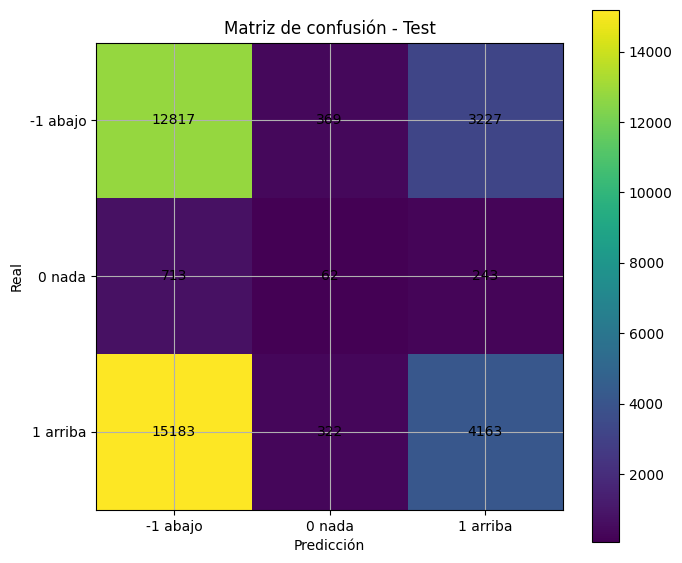

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.45      0.78      0.57     16413
      0 nada       0.08      0.06      0.07      1018
    1 arriba       0.55      0.21      0.30     19668

    accuracy                           0.46     37099
   macro avg       0.36      0.35      0.31     37099
weighted avg       0.49      0.46      0.41     37099

Balance train


,label,count,pct
0,-1,136354,0.455613
1,0,133,0.000444
2,1,162789,0.543943


Balance validation


,label,count,pct
0,-1,14216,0.427446
1,1,19042,0.572554


Balance test


,label,count,pct
0,-1,16769,0.453694
1,0,21,0.000568
2,1,20171,0.545737


Entrenando cnn_tb_iw_30_ow_90_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7316152563670055), np.int64(1): np.float64(750.0651629072681), np.int64(2): np.float64(0.6128096288242244)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.9524 - sparse_categorical_accuracy: 0.4927 - val_loss: 0.8745 - val_sparse_categorical_accuracy: 0.5253 - learning_rate: 0.0010
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2047 - sparse_categorical_accuracy: 0.4934 - val_loss: 0.8123 - val_sparse_categorical_accuracy: 0.5011 - learning_rate: 0.0010
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2402 - sparse_categorical_accuracy: 0.4854 - val_loss: 0.8480 - val_sparse_categorical_accuracy: 0.4980 - learning_rate: 0.0010
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2420 - sparse_categorical_accuracy: 0.4867 - val_loss: 0.7461 - val_sparse_categorical_accuracy: 0.5253 - learning_rate: 0.0010
Epoch 5/1000
20

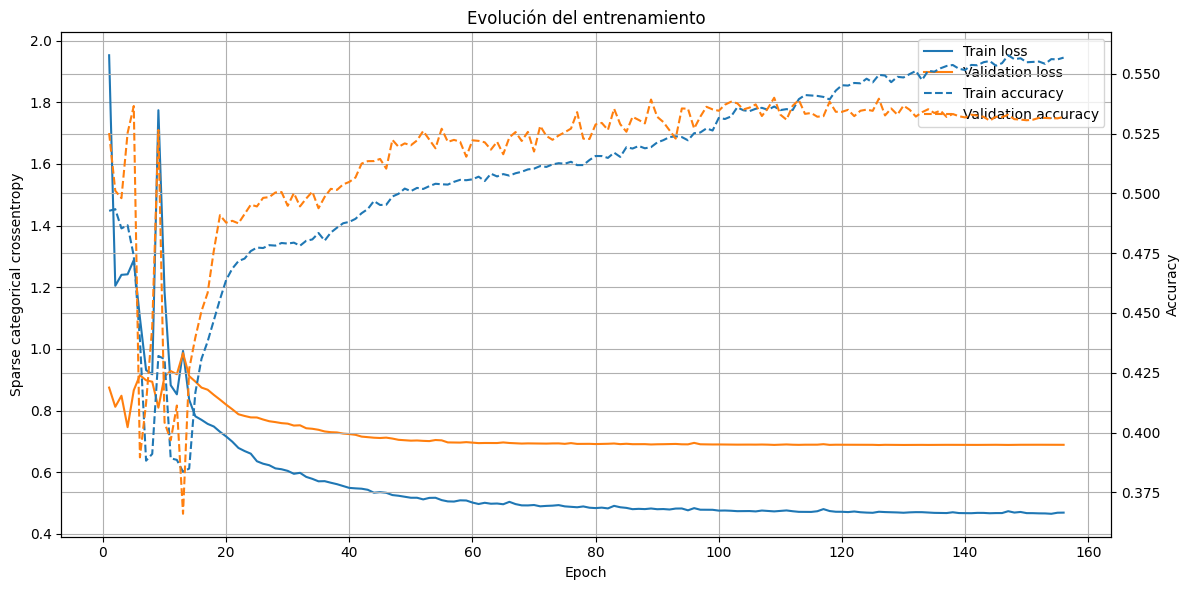

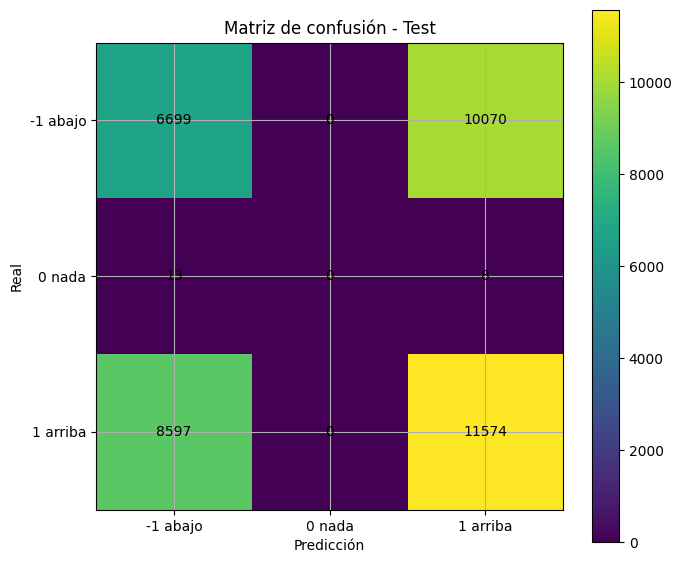

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.44      0.40      0.42     16769
      0 nada       0.00      0.00      0.00        21
    1 arriba       0.53      0.57      0.55     20171

    accuracy                           0.49     36961
   macro avg       0.32      0.32      0.32     36961
weighted avg       0.49      0.49      0.49     36961

Balance train


,label,count,pct
0,-1,65191,0.217495
1,0,157749,0.526293
2,1,76796,0.256212


Balance validation


,label,count,pct
0,-1,6656,0.199718
1,0,18698,0.561047
2,1,7973,0.239235


Balance test


,label,count,pct
0,-1,7646,0.206610
1,0,20613,0.557003
2,1,8748,0.236388


Entrenando cnn_tb_iw_90_ow_5_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(1.5326041938304367), np.int64(1): np.float64(0.6333605918262556), np.int64(2): np.float64(1.301005260690661)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0985 - sparse_categorical_accuracy: 0.3426 - val_loss: 1.0942 - val_sparse_categorical_accuracy: 0.4516 - learning_rate: 0.0010
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0979 - sparse_categorical_accuracy: 0.3382 - val_loss: 1.0962 - val_sparse_categorical_accuracy: 0.3547 - learning_rate: 0.0010
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0977 - sparse_categorical_accuracy: 0.3423 - val_loss: 1.0922 - val_sparse_categorical_accuracy: 0.4003 - learning_rate: 0.0010
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0970 - sparse_categorical_accuracy: 0.3632 - val_loss: 1.0838 - val_sparse_categorical_accuracy: 0.4675 - learning_rate: 0.0010
Epoch 5/1000
204

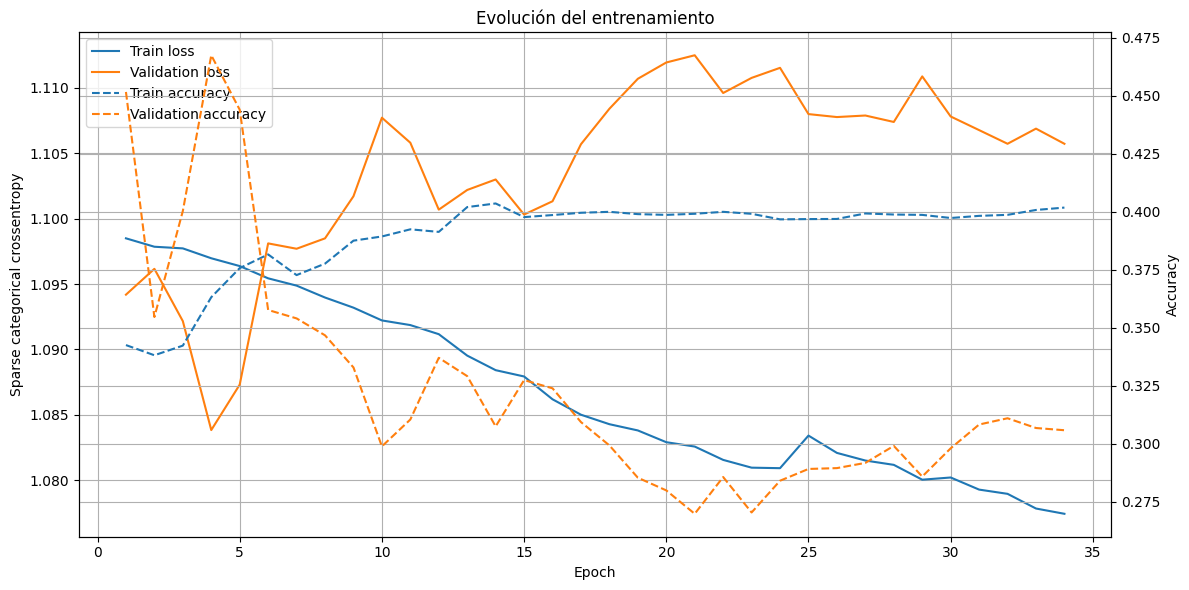

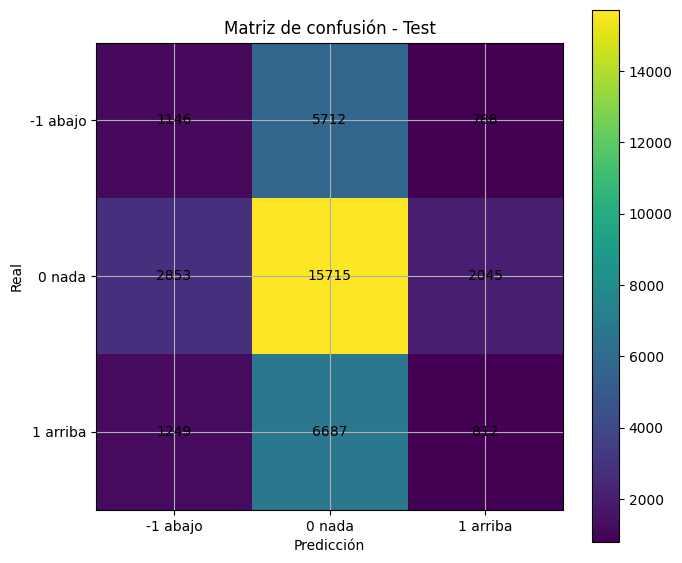

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.22      0.15      0.18      7646
      0 nada       0.56      0.76      0.65     20613
    1 arriba       0.22      0.09      0.13      8748

    accuracy                           0.48     37007
   macro avg       0.33      0.34      0.32     37007
weighted avg       0.41      0.48      0.43     37007

Balance train


,label,count,pct
0,-1,133219,0.445138
1,0,5971,0.019951
2,1,160086,0.534911


Balance validation


,label,count,pct
0,-1,13935,0.418997
1,0,794,0.023874
2,1,18529,0.557129


Balance test


,label,count,pct
0,-1,16360,0.442629
1,0,1008,0.027272
2,1,19593,0.530099


Entrenando cnn_tb_iw_90_ow_30_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7488321235459406), np.int64(1): np.float64(16.707195891252162), np.int64(2): np.float64(0.6231567199297045)}
Epoch 1/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0969 - sparse_categorical_accuracy: 0.3345 - val_loss: 1.1132 - val_sparse_categorical_accuracy: 0.2206 - learning_rate: 0.0010
Epoch 2/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0887 - sparse_categorical_accuracy: 0.3029 - val_loss: 1.1102 - val_sparse_categorical_accuracy: 0.2837 - learning_rate: 0.0010
Epoch 3/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0866 - sparse_categorical_accuracy: 0.3131 - val_loss: 1.1100 - val_sparse_categorical_accuracy: 0.2834 - learning_rate: 0.0010
Epoch 4/1000
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0846 - sparse_categorical_accuracy: 0.3124 - val_loss: 1.1213 - val_sparse_categorical_accuracy: 0.2841 - learning_rate: 0.0010
Epoch 5/1000
2

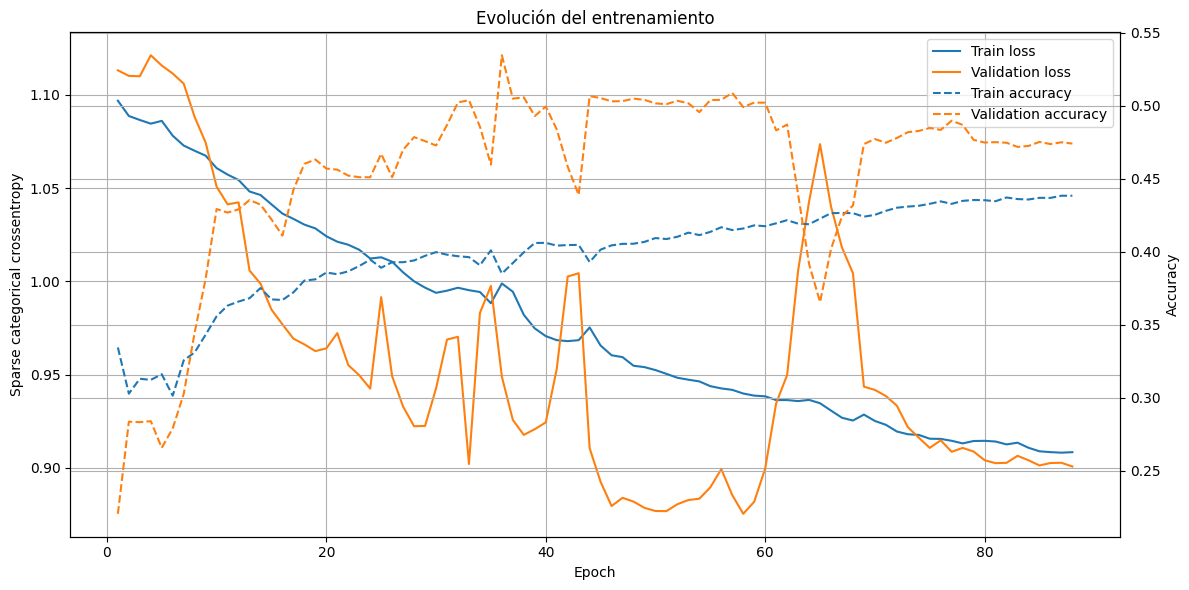

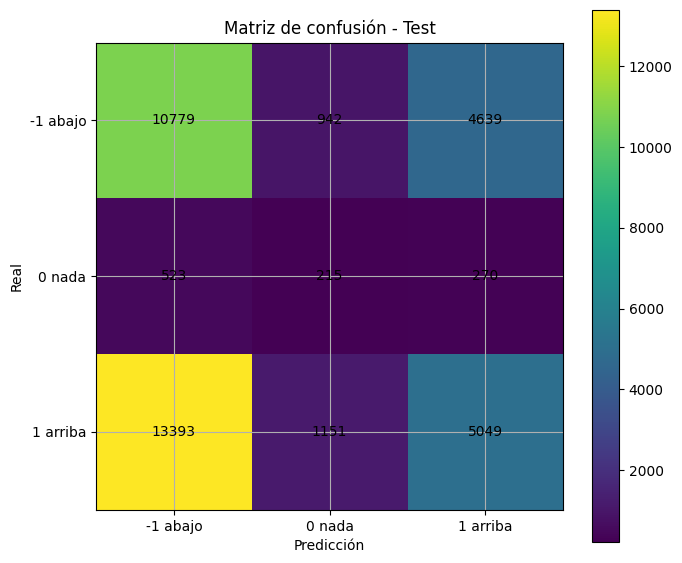

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.44      0.66      0.53     16360
      0 nada       0.09      0.21      0.13      1008
    1 arriba       0.51      0.26      0.34     19593

    accuracy                           0.43     36961
   macro avg       0.35      0.38      0.33     36961
weighted avg       0.46      0.43      0.42     36961

Balance train


,label,count,pct
0,-1,135340,0.453934
1,0,133,0.000446
2,1,162676,0.545620


Balance validation


,label,count,pct
0,-1,14142,0.426696
1,1,19001,0.573304


Balance test


,label,count,pct
0,-1,16719,0.454037
1,0,21,0.000570
2,1,20083,0.545393


Entrenando cnn_tb_iw_90_ow_90_pt_2_sl_2 | params=17,093 | kernel=3
Class weights: {np.int64(0): np.float64(0.7343209694103738), np.int64(1): np.float64(747.2406015037594), np.int64(2): np.float64(0.610926012441909)}
Epoch 1/1000
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.6298 - sparse_categorical_accuracy: 0.4688 - val_loss: 0.8977 - val_sparse_categorical_accuracy: 0.4904 - learning_rate: 0.0010
Epoch 2/1000
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3984 - sparse_categorical_accuracy: 0.4803 - val_loss: 0.8267 - val_sparse_categorical_accuracy: 0.5153 - learning_rate: 0.0010
Epoch 3/1000
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1352 - sparse_categorical_accuracy: 0.4786 - val_loss: 0.8961 - val_sparse_categorical_accuracy: 0.4743 - learning_rate: 0.0010
Epoch 4/1000
203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0119 - sparse_categorical_accuracy: 0.4561 - val_loss: 0.8760 - val_sparse_categorical_accuracy: 0.4607 - learning_rate: 0.0010
Epoch 5/1000
203

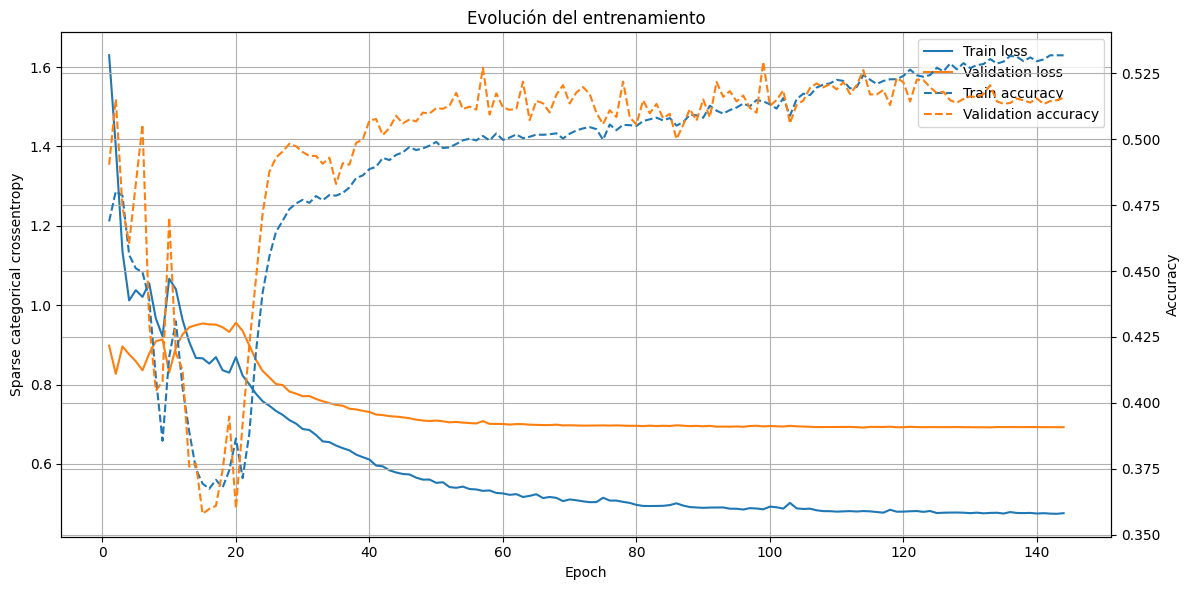

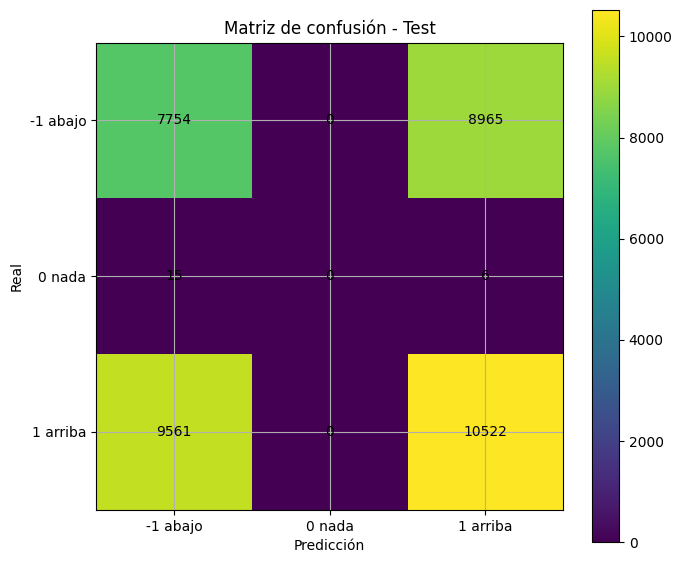

Classification report - Test
              precision    recall  f1-score   support

    -1 abajo       0.45      0.46      0.46     16719
      0 nada       0.00      0.00      0.00        21
    1 arriba       0.54      0.52      0.53     20083

    accuracy                           0.50     36823
   macro avg       0.33      0.33      0.33     36823
weighted avg       0.50      0.50      0.50     36823



In [34]:
input_windows = [5, 10, 30, 90]
output_windows = [5, 30, 90]

# Lanzar el grid completo.

summary_df, tb_results = run_triple_barrier_grid(
     features=features,
     prices=prices_close,
     volatility=daily_volatility,
     input_windows=input_windows,
     output_windows=output_windows,
     pt_mult=2.0,
     sl_mult=2.0,
     results_dir=RESULTS_DIR,
     epochs=1000,
     batch_size=64,
     kernel_size=3,
     filters_1=32,
     filters_2=64,
     dense_units=64,
     dropout_rate=0.20,
     learning_rate=1e-3,
     verbose=1,
 )

# summary_df

## 13. Plot del grid guardado

Lee `history.csv` y `metrics.csv` desde las carpetas guardadas.

In [30]:
def plot_saved_triple_barrier_grid(
    results_dir: Path,
    input_windows: List[int],
    output_windows: List[int],
    pt_mult: float = 1.0,
    sl_mult: float = 1.0,
    save_path: Optional[Path] = None,
) -> None:
    """Pinta loss de todos los experimentos guardados."""
    fig, axes = plt.subplots(
        nrows=len(input_windows),
        ncols=len(output_windows),
        figsize=(22, 18),
        squeeze=False,
    )

    for i, input_window in enumerate(input_windows):
        for j, output_window in enumerate(output_windows):
            ax = axes[i, j]
            experiment_name = (
                f"cnn_tb_iw_{input_window}_ow_{output_window}"
                f"_pt_{pt_mult:g}_sl_{sl_mult:g}"
            )
            experiment_dir = results_dir / experiment_name
            history_path = experiment_dir / "history.csv"
            metrics_path = experiment_dir / "metrics.csv"

            if not history_path.exists() or not metrics_path.exists():
                ax.set_visible(False)
                continue

            history_df = pd.read_csv(history_path)
            metrics = pd.read_csv(metrics_path).iloc[0]

            ax.plot(history_df["epoch"], history_df["loss"], label="train loss")
            ax.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
            ax.set_title(
                f"IW={input_window}, OW={output_window}"
                f"test F1={metrics['test_macro_f1']:.3f} | "
                f"bal acc={metrics['test_balanced_accuracy']:.3f}",
                fontsize=11,
            )
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.25)

    fig.suptitle("CNN Triple Barrera - Loss por combinación", fontsize=20, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

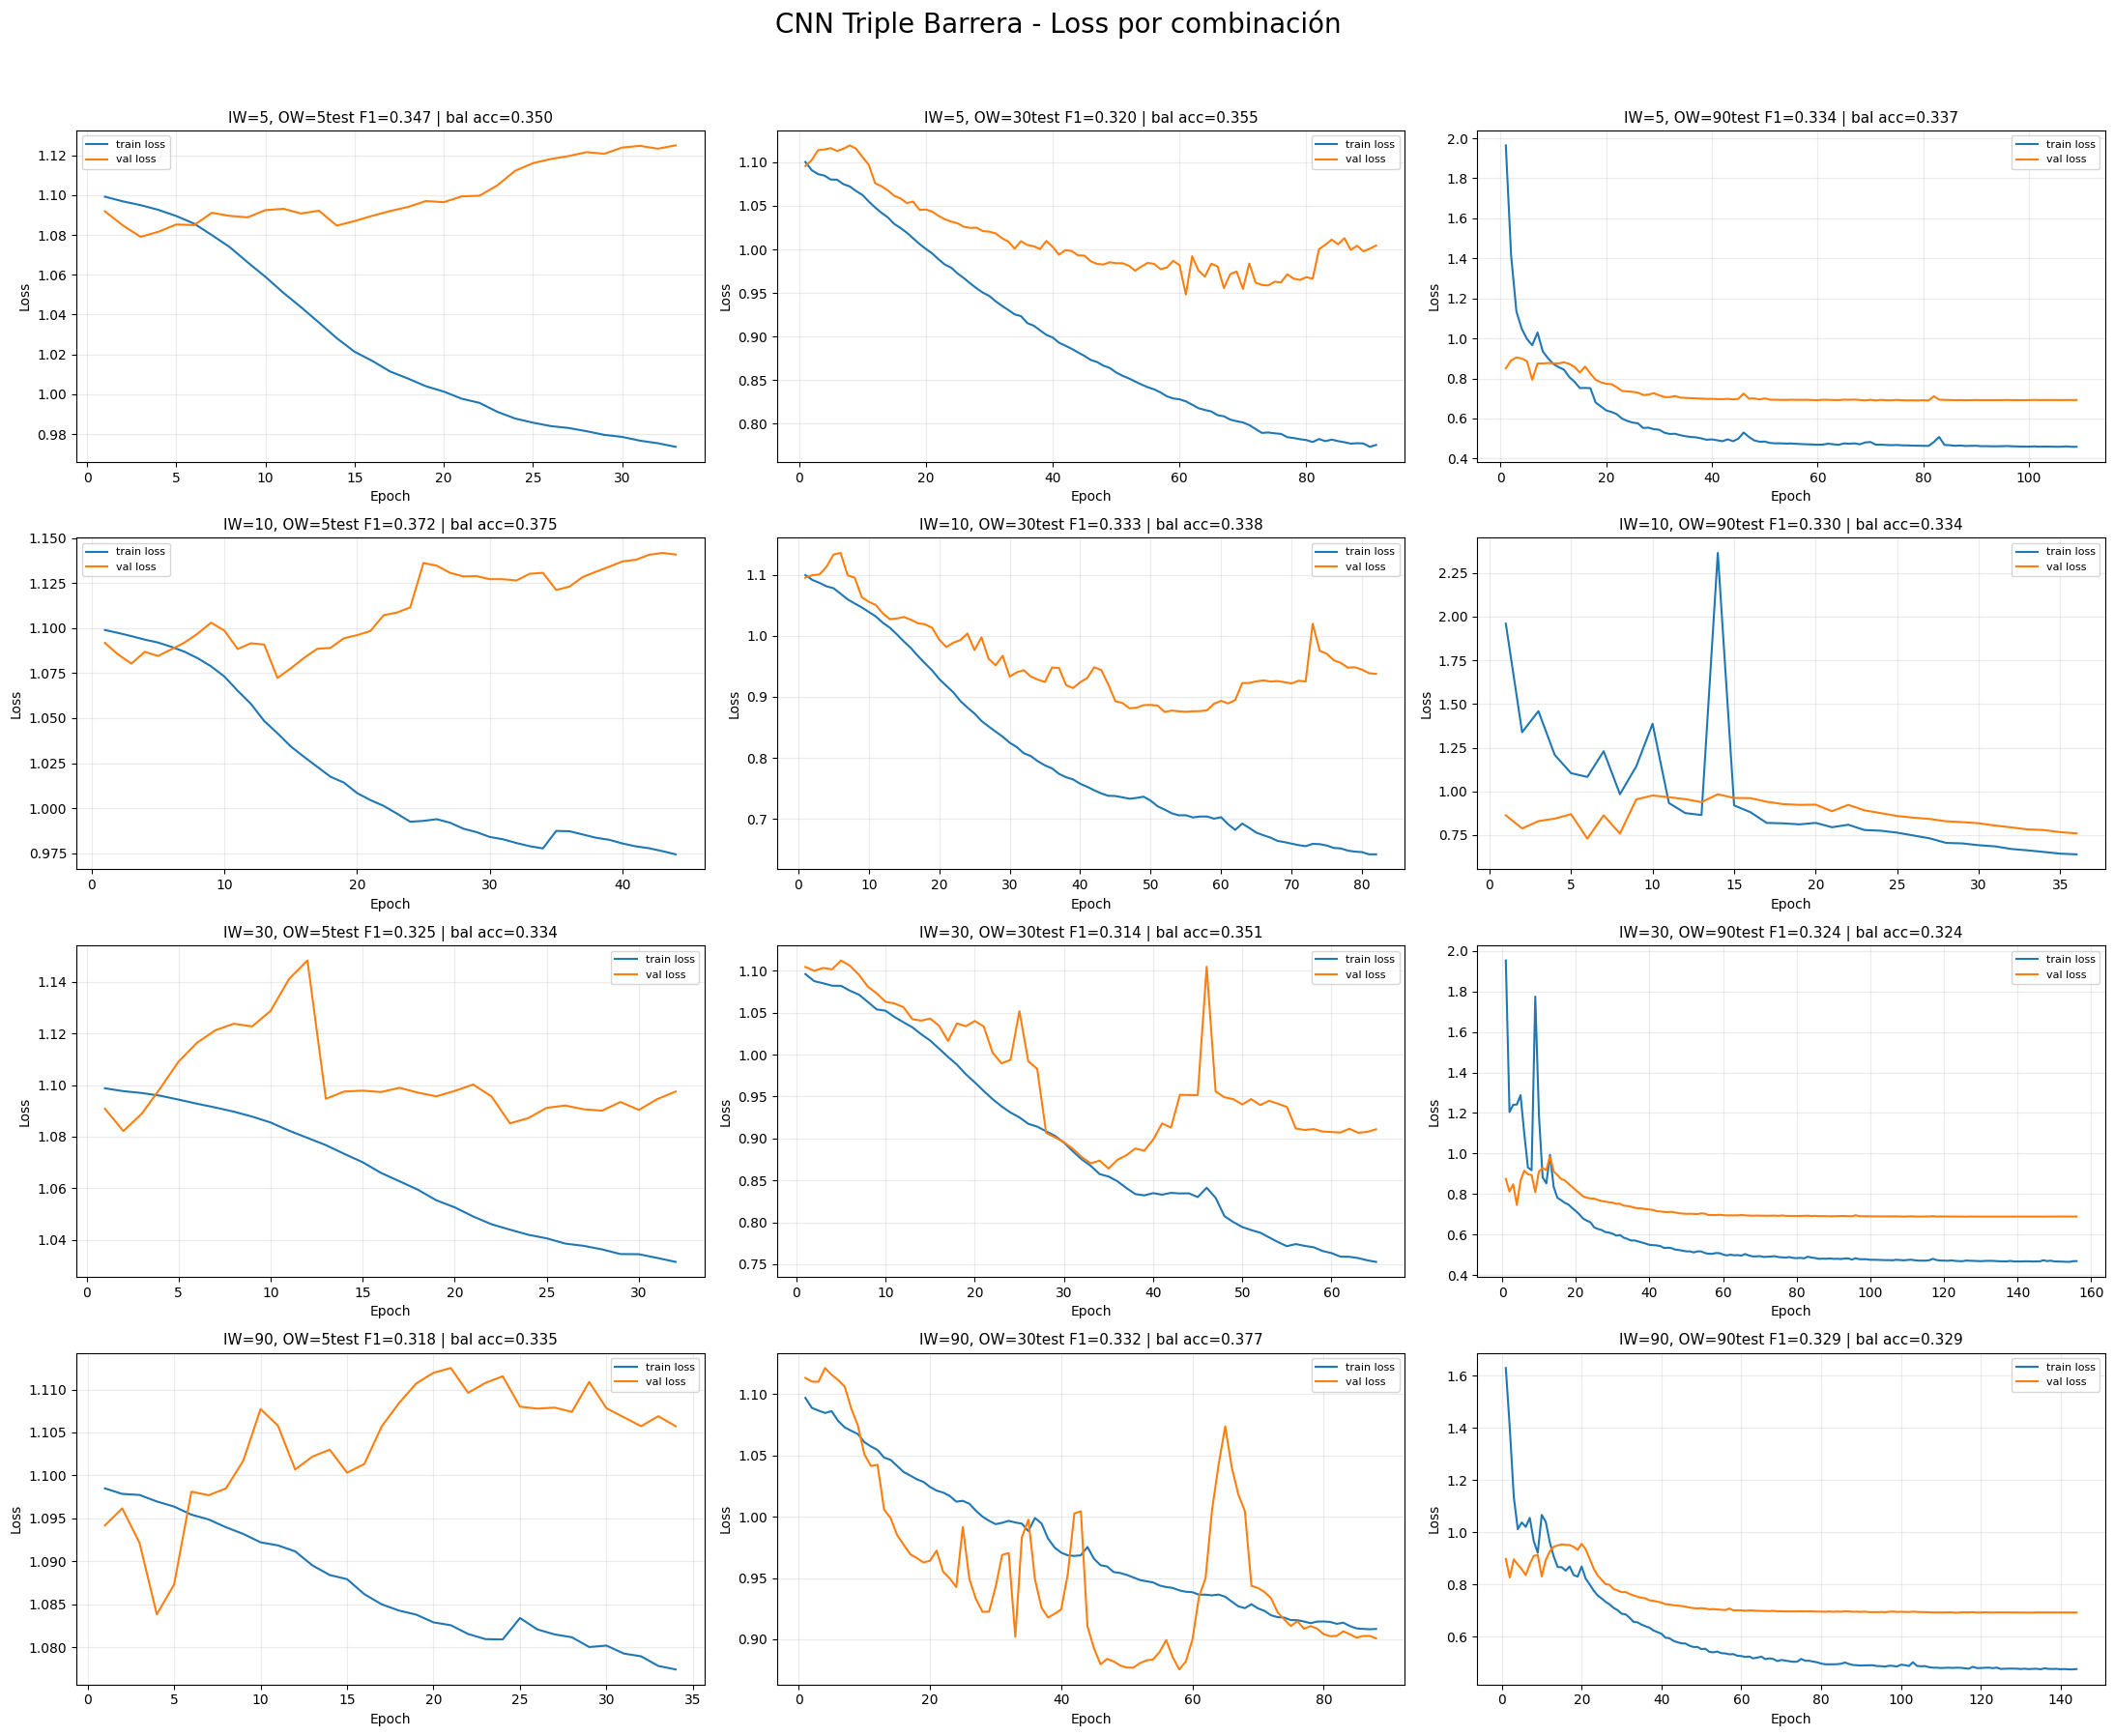

In [ ]:
# Descomenta después de lanzar el grid completo.

plot_saved_triple_barrier_grid(
     results_dir=RESULTS_DIR,
     input_windows=input_windows,
     output_windows=output_windows,
     pt_mult=2.0,
     sl_mult=2.0,
     save_path=RESULTS_DIR / "grid_training_loss_2_2.png",
)